# 006 — Choosing the thresholds

Step 1.6. Every transaction gets one of three decisions, and each has a price:

| decision | when | cost |
|---|---|---|
| **block** | risk >= block threshold | `false_block_cost` per legitimate customer blocked |
| **review** | review threshold <= risk < block threshold | `review_cost` per transaction reviewed |
| **approve** | risk < review threshold | amount + `chargeback_fee` per fraud let through |

The thresholds are chosen on **training data** (its 378 fraud cases were never shown to the forest), then confirmed **once** on the test set.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import settings
from src.ml.evaluate import threshold_table
from src.ml.preprocess import load_splits
from src.ml.thresholds import (
    CANDIDATE_THRESHOLDS, Costs, approve_all_cost_per_100k, choose_thresholds,
    costs_from_settings, policy_costs,
)
from src.ml.isolation_forest import fit_risk_model

pd.set_option("display.float_format", "{:,.4f}".format)
pd.set_option("display.width", 200)

## 2. Train, score, and state the cost assumptions

In [2]:
X_train, X_test, y_train, y_test = load_splits()
risk_model = fit_risk_model(X_train, y_train)
train_risk = risk_model.risk(X_train)
test_risk = risk_model.risk(X_test)

costs = costs_from_settings()
approve_all_train = approve_all_cost_per_100k(y_train, X_train["Amount"], costs)

print("assumptions (edit in .env):")
print(f"  analyst review:           ${costs.review_cost:.2f} per transaction")
print(f"  wrongly blocked customer: ${costs.false_block_cost:.2f}")
print(f"  missed fraud:             amount + ${costs.chargeback_fee:.2f} chargeback fee")
print(f"  analyst capacity:         at most {settings.max_review_rate:.1%} of transactions reviewed")
print()
print(f"no model (approve everything): ${approve_all_train:,.0f} per 100k transactions")

assumptions (edit in .env):
  analyst review:           $5.00 per transaction
  wrongly blocked customer: $50.00
  missed fraud:             amount + $15.00 chargeback fee
  analyst capacity:         at most 2.0% of transactions reviewed

no model (approve everything): $21,806 per 100k transactions


## 3. Price every threshold pair and choose

In [3]:
train_costs = policy_costs(y_train, train_risk, X_train["Amount"], costs)
choice = choose_thresholds(train_costs, max_review_rate=settings.max_review_rate)

print(f"priced {len(train_costs):,} (review, block) pairs")
print(f"review threshold: {choice.review_threshold}")
print(f"block threshold:  {choice.block_threshold}  (None = never auto-block)")
print(f"reviewed: {choice.review_rate:.2%} of transactions | blocked: {choice.block_rate:.2%}")
print(f"cost: ${choice.cost_per_100k:,.0f} per 100k  vs  ${approve_all_train:,.0f} with no model "
      f"({1 - choice.cost_per_100k / approve_all_train:.0%} saved)")

cheapest = train_costs[train_costs["review_rate"] <= settings.max_review_rate].nsmallest(5, "cost_per_100k")
cheapest[["review_threshold", "block_threshold", "review_rate", "block_rate", "fraud_stopped", "cost_per_100k"]]

priced 5,150 (review, block) pairs
review threshold: 0.983
block threshold:  None  (None = never auto-block)
reviewed: 1.81% of transactions | blocked: 0.00%
cost: $15,593 per 100k  vs  $21,806 with no model (28% saved)


,review_threshold,block_threshold,review_rate,block_rate,fraud_stopped,cost_per_100k
4997,0.9830,NaN,0.0181,0.0000,0.6640,"15,593.0434"
4979,0.9820,NaN,0.0191,0.0000,0.6772,"15,736.8403"
5072,0.9880,NaN,0.0130,0.0000,0.6005,"15,945.4577"
5059,0.9870,NaN,0.0140,0.0000,0.6111,"16,326.5398"
5014,0.9840,NaN,0.0170,0.0000,0.6481,"16,369.2308"


## 4. Why nothing gets auto-blocked

In [4]:
break_even = 1 - costs.review_cost / costs.false_block_cost
by_threshold = threshold_table(y_train, train_risk, thresholds=CANDIDATE_THRESHOLDS)
best = by_threshold.loc[by_threshold["precision"].idxmax()]

print(f"Blocking a transaction instead of reviewing it saves ${costs.review_cost:.0f},")
print(f"but costs ${costs.false_block_cost:.0f} whenever the customer was legitimate.")
print(f"So blocking only pays when precision > 1 - {costs.review_cost:.0f}/{costs.false_block_cost:.0f} = {break_even:.0%}.")
print()
print(f"best precision at any candidate threshold (train): {best['precision']:.1%} at risk >= {best['threshold']}")

Blocking a transaction instead of reviewing it saves $5,
but costs $50 whenever the customer was legitimate.
So blocking only pays when precision > 1 - 5/50 = 90%.

best precision at any candidate threshold (train): 22.9% at risk >= 0.999


## 5. The cost curve

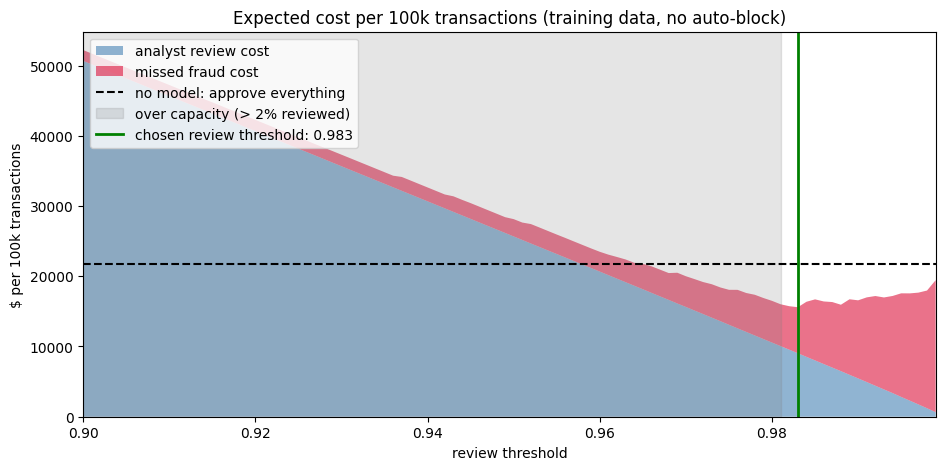

In [5]:
no_block = train_costs[train_costs["block_threshold"].isna()].sort_values("review_threshold")

fig, ax = plt.subplots(figsize=(11, 5))
ax.stackplot(no_block["review_threshold"], no_block["review_cost"], no_block["missed_fraud_cost"],
             labels=["analyst review cost", "missed fraud cost"], colors=["steelblue", "crimson"], alpha=0.6)
ax.axhline(approve_all_train, ls="--", color="black", label="no model: approve everything")

over_capacity = no_block.loc[no_block["review_rate"] > settings.max_review_rate, "review_threshold"]
if not over_capacity.empty:
    ax.axvspan(no_block["review_threshold"].min(), over_capacity.max(), color="gray", alpha=0.2,
               label=f"over capacity (> {settings.max_review_rate:.0%} reviewed)")
ax.axvline(choice.review_threshold, color="green", lw=2, label=f"chosen review threshold: {choice.review_threshold}")

ax.set(title="Expected cost per 100k transactions (training data, no auto-block)",
       xlabel="review threshold", ylabel="$ per 100k transactions", xlim=(0.9, 0.999))
ax.legend(loc="upper left")
plt.show()

## 6. How much do the assumptions matter?

In [6]:
rows = []
for review_cost in [2, 5, 10]:
    for false_block_cost in [20, 50, 200]:
        scenario = Costs(review_cost=review_cost, false_block_cost=false_block_cost, chargeback_fee=costs.chargeback_fee)
        pick = choose_thresholds(policy_costs(y_train, train_risk, X_train["Amount"], scenario),
                                 max_review_rate=settings.max_review_rate)
        baseline = approve_all_cost_per_100k(y_train, X_train["Amount"], scenario)
        rows.append({
            "review_cost": review_cost,
            "false_block_cost": false_block_cost,
            "review_threshold": pick.review_threshold,
            "block_threshold": pick.block_threshold,
            "reviewed_%": pick.review_rate * 100,
            "saving_vs_no_model_%": 100 * (1 - pick.cost_per_100k / baseline),
        })
pd.DataFrame(rows)

,review_cost,false_block_cost,review_threshold,block_threshold,reviewed_%,saving_vs_no_model_%
0,2,20,0.9830,None,1.8076,53.3608
1,2,50,0.9830,None,1.8076,53.3608
2,2,200,0.9830,None,1.8076,53.3608
3,5,20,0.9830,None,1.8076,28.4917
4,5,50,0.9830,None,1.8076,28.4917
5,5,200,0.9830,None,1.8076,28.4917
6,10,20,0.9980,None,0.2419,12.0499
7,10,50,0.9980,None,0.2419,12.0499
8,10,200,0.9980,None,0.2419,12.0499


## 7. Confirm once on the test set

In [7]:
def price_choice(y, risk, amounts):
    row = policy_costs(y, risk, amounts, costs,
                       review_candidates=[choice.review_threshold],
                       block_candidates=[choice.block_threshold]).iloc[0]
    baseline = approve_all_cost_per_100k(y, amounts, costs)
    return {
        "reviewed_%": row["review_rate"] * 100,
        "blocked_%": row["block_rate"] * 100,
        "fraud_stopped_%": row["fraud_stopped"] * 100,
        "fraud_loss_stopped_%": row["fraud_loss_stopped"] * 100,
        "cost_per_100k": row["cost_per_100k"],
        "no_model_cost_per_100k": baseline,
        "saving_%": 100 * (1 - row["cost_per_100k"] / baseline),
    }

pd.DataFrame({
    "train": price_choice(y_train, train_risk, X_train["Amount"]),
    "test": price_choice(y_test, test_risk, X_test["Amount"]),
})

,train,test
reviewed_%,1.8076,1.8768
blocked_%,0.0000,0.0000
fraud_stopped_%,66.4021,66.3158
fraud_loss_stopped_%,69.9403,67.0581
cost_per_100k,"15,593.0434","18,783.2094"
no_model_cost_per_100k,"21,805.9212","28,532.9539"
saving_%,28.4917,34.1701


In [8]:
threshold_table(y_test, test_risk, thresholds=[choice.review_threshold], amounts=X_test["Amount"])

,threshold,flagged,flagged_%,tp,fp,fn,precision,recall,f1,normal_flagged_%,alerts_per_fraud,fraud_amount_caught_%
0,0.9830,1065,1.8768,63,1002,32,0.0592,0.6632,0.1086,1.7687,16.9048,67.1298


## Step 1.6 findings

**Decision: review every transaction with risk >= 0.983. Never auto-block.**

> We review the riskiest ~1.9% of transactions because a $5 review is cheaper than letting fraud through, and we never auto-block because a $50 false block only beats a $5 review when the model is right 90% of the time, and this model peaks at 23%.

**Chosen on training data**
- 5,150 (review, block) threshold pairs priced; cheapest within capacity: review 0.983, no block.
- Reviews 1.81% of transactions (capacity is 2%), stops 66.4% of fraud cases and 69.9% of fraud losses.
- $15,593 per 100k transactions vs $21,806 with no model: **28% cheaper**.

**Confirmed once on the test set**

| | train | test |
|---|---|---|
| reviewed | 1.81% | 1.88% |
| fraud cases stopped | 66.4% | 66.3% |
| fraud losses stopped | 69.9% | 67.1% |
| saving vs no model | 28% | 34% |

On test that is 63 of 95 fraud caught, 5.9% precision, 17 alerts per fraud caught. The decision carried over from training data without re-tuning.

**Why no auto-block**
- Blocking instead of reviewing saves $5 but costs $50 when the customer was legitimate, so it only pays above 90% precision.
- The best precision at any threshold is 22.9% (train, risk >= 0.999).
- In the sensitivity table, false-block costs from $20 to $200 never change this. A supervised model (Step 1.7) might reach the precision where blocking makes sense.

**What the assumptions change**
- Review cost $2 or $5: review threshold 0.983, 1.8% reviewed.
- Review cost $10: threshold rises to 0.998, only 0.24% reviewed, and the saving shrinks to 12%.
- The costs are illustrative, not industry data. They live in `.env`; change them and re-run this notebook.

**Caveat: the third decimal is noise.** Cost jumps from $15,593 at 0.983 to $16,369 at 0.984 because single large fraud amounts cross the line. Anything from about 0.982 to 0.988 performs about the same.

**Compared with 0.99 from Step 1.5:** 0.983 reviews about 0.7% more traffic (1.88% vs 1.16% on test) but catches 12 more points of fraud (66% vs 54%), and the cost model says that trade is worth it.

**Config updated:** `REVIEW_THRESHOLD=0.983`, `BLOCK_THRESHOLD=none`, plus `REVIEW_COST`, `FALSE_BLOCK_COST`, `CHARGEBACK_FEE`, `MAX_REVIEW_RATE` in `.env` and `.env.example`.